<a href="https://colab.research.google.com/github/vineetsalar88/CompilerDesign/blob/master/March26/23MarchConvNeXt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train_dir = "/content/drive/MyDrive/ResearchData/March26/DatasetTrainVsTest10march/train"
val_dir = "/content/drive/MyDrive/ResearchData/March26/DatasetTrainVsTest10march/val"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(train_dir))

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.convnext_tiny(pretrained=True)

# Replace classifier
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 189MB/s] 


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [ ]:
EPOCHS = 15

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f}")

    scheduler.step()



Epoch 1/15
Train Loss: 1.1289 | Val Loss: 1.3315 | Acc: 0.4698
Epoch 2/15
Train Loss: 0.7702 | Val Loss: 0.7595 | Acc: 0.6619
Epoch 3/15
Train Loss: 0.4680 | Val Loss: 0.8633 | Acc: 0.6619
Epoch 4/15
Train Loss: 0.3737 | Val Loss: 0.7273 | Acc: 0.7189
Epoch 5/15
Train Loss: 0.2645 | Val Loss: 0.8665 | Acc: 0.6762
Epoch 6/15
Train Loss: 0.1752 | Val Loss: 0.8118 | Acc: 0.7189
Epoch 7/15
Train Loss: 0.0737 | Val Loss: 0.7776 | Acc: 0.7260
Epoch 8/15
Train Loss: 0.0462 | Val Loss: 0.8014 | Acc: 0.7260
Epoch 9/15
Train Loss: 0.0254 | Val Loss: 0.8156 | Acc: 0.7367
Epoch 10/15
Train Loss: 0.0216 | Val Loss: 0.9201 | Acc: 0.7153
Epoch 11/15
Train Loss: 0.0131 | Val Loss: 0.9094 | Acc: 0.7402
Epoch 12/15
Train Loss: 0.0115 | Val Loss: 0.9058 | Acc: 0.7367
Epoch 13/15
Train Loss: 0.0149 | Val Loss: 0.9019 | Acc: 0.7331
Epoch 14/15
Train Loss: 0.0130 | Val Loss: 0.9399 | Acc: 0.7367
Epoch 15/15
Train Loss: 0.0093 | Val Loss: 0.9409 | Acc: 0.7295


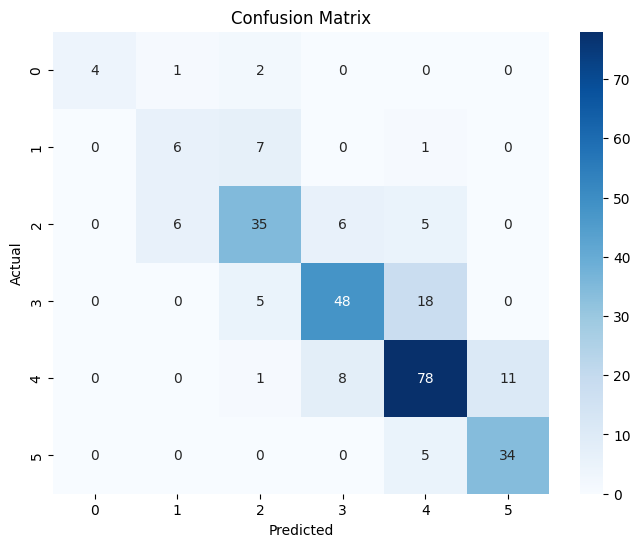

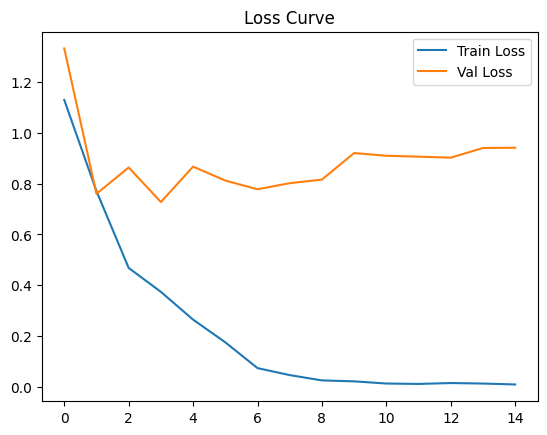

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
torch.save(model.state_dict(), "convnext_model.pth")
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()